In [22]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [23]:
df_clean = pd.read_csv('../data/data_clean.csv')
print(df_clean.columns)
df_labels = df_clean.copy()[['class_primary','class_secondary','attack']]
df_names = df_clean['english_name']
df_data = df_clean.drop(columns=['english_name','class_primary','class_secondary','attack'])

Index(['gen', 'english_name', 'percent_male', 'percent_female', 'height_m',
       'weight_kg', 'capture_rate', 'base_egg_steps', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'against_normal',
       'against_fire', 'against_water', 'against_electric', 'against_grass',
       'against_ice', 'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychict', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity',
       'class_primary', 'class_secondary'],
      dtype='object')


### EDA

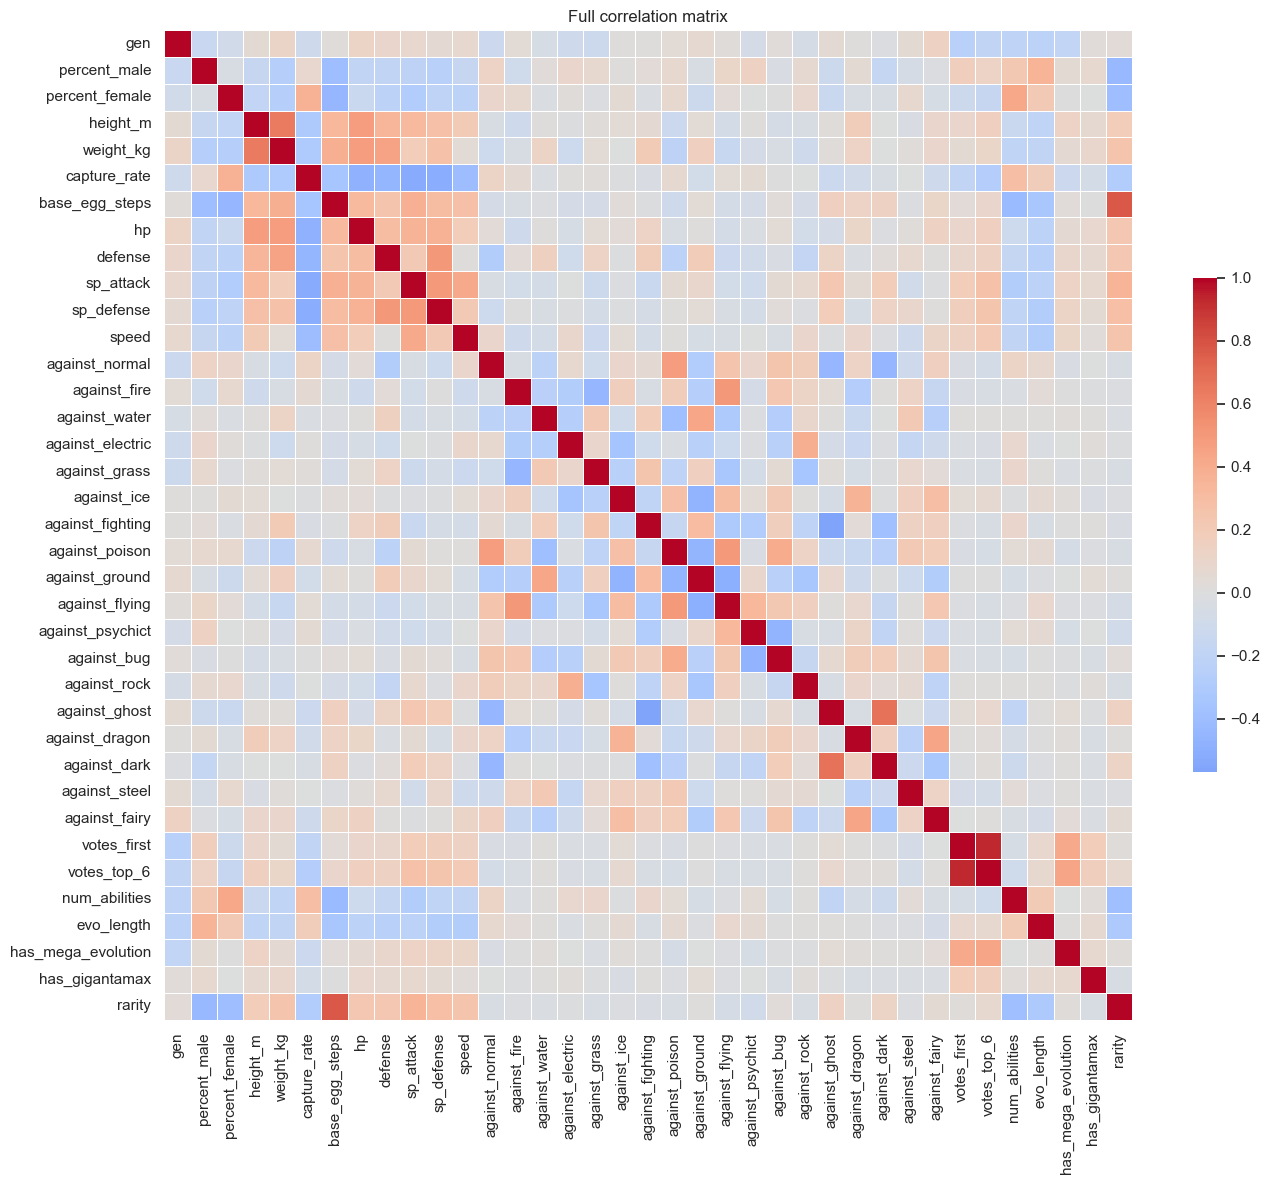

Top correlated variable pairs (by absolute correlation):
            var1           var2  abs_corr
     votes_first    votes_top_6  0.929725
  base_egg_steps         rarity  0.774943
   against_ghost   against_dark  0.672901
        height_m      weight_kg  0.632433
against_fighting  against_ghost  0.569611
    capture_rate      sp_attack  0.521414
    capture_rate     sp_defense  0.508779
         defense     sp_defense  0.503886
    against_fire against_flying  0.501307
  against_poison against_flying  0.494749
       sp_attack     sp_defense  0.492859
  against_ground against_flying  0.490272
    capture_rate             hp  0.484615
        height_m             hp  0.482557
  against_normal against_poison  0.477967
       weight_kg             hp  0.476551
against_psychict    against_bug  0.469059
     against_ice against_ground  0.466493
  against_poison against_ground  0.462774
    capture_rate        defense  0.458208


In [24]:
# compute correlation matrix for all numeric parameters
numeric = df_data.select_dtypes(include=[np.number])
corr = numeric.corr()

plt.figure(figsize=(14, 12))
sns.set(style="white")
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": .5})
plt.title("Full correlation matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150)
plt.show()

# show top absolute correlations (excluding self-correlations) as a quick summary
abs_corr = corr.abs()
pairs = (
    abs_corr.unstack()
    .reset_index()
    .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'abs_corr'})
)
pairs = pairs[pairs['var1'] != pairs['var2']]
# keep unique pairs (unordered) and sort by absolute correlation
pairs['pair_key'] = pairs.apply(lambda r: tuple(sorted((r['var1'], r['var2']))), axis=1)
top_pairs = pairs.drop_duplicates(subset='pair_key').sort_values('abs_corr', ascending=False)

print("Top correlated variable pairs (by absolute correlation):")
print(top_pairs[['var1', 'var2', 'abs_corr']].head(20).to_string(index=False))



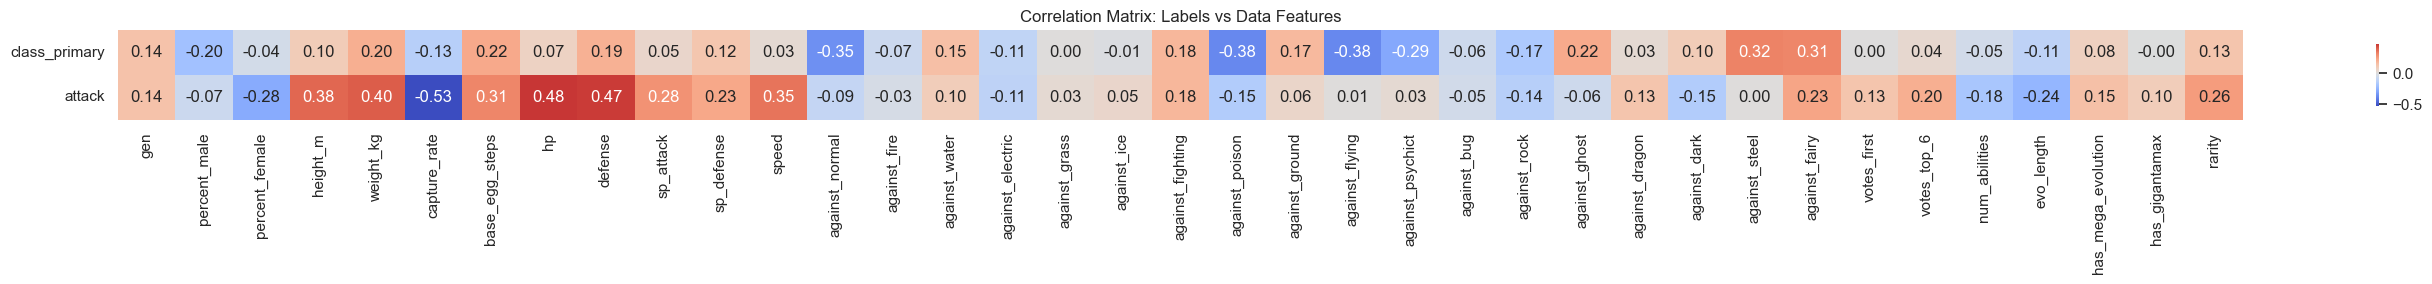

Top correlated label-feature pairs (by absolute correlation):
        label          feature  abs_corr
       attack     capture_rate  0.529879
       attack               hp  0.475622
       attack          defense  0.465929
       attack        weight_kg  0.402339
       attack         height_m  0.384079
class_primary   against_poison  0.379457
class_primary   against_flying  0.376908
class_primary   against_normal  0.354954
       attack            speed  0.352520
class_primary    against_steel  0.318723
       attack   base_egg_steps  0.313042
class_primary    against_fairy  0.312873
class_primary against_psychict  0.287448
       attack        sp_attack  0.281052
       attack   percent_female  0.276500
       attack           rarity  0.256222
       attack       evo_length  0.242054
       attack    against_fairy  0.233873
       attack       sp_defense  0.226664
class_primary   base_egg_steps  0.220618


In [25]:
# Compute correlation matrix between all columns in df_labels (excluding secondary_type) and all columns in df_data
label_cols = ['class_primary', 'attack']
corr_matrix = df_labels[label_cols].join(df_data).corr()

# Extract only correlations between label columns and data columns (exclude label-label and data-data)
corr_pairs = []
for label in label_cols:
    for col in df_data.columns:
        corr_val = corr_matrix.loc[label, col]
        corr_pairs.append((label, col, corr_val))

# Convert to DataFrame and sort by absolute correlation
corr_df = pd.DataFrame(corr_pairs, columns=['label', 'feature', 'corr'])
corr_df['abs_corr'] = corr_df['corr'].abs()
top_corr = corr_df.sort_values('abs_corr', ascending=False).drop(columns=['corr'])

# Show correlation matrix as heatmap (very wide)
plt.figure(figsize=(28, 3))
sns.heatmap(
    corr_matrix.loc[label_cols, df_data.columns],
    annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"shrink": .7}
)
plt.title("Correlation Matrix: Labels vs Data Features")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print most correlated pairs
print("Top correlated label-feature pairs (by absolute correlation):")
print(top_corr.head(20).to_string(index=False))

Attack quantiles by generation:


C:\Users\jenda\AppData\Local\Temp\ipykernel_47092\899705391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=temp['gen_int'], y=df_labels['attack'], palette="Set3")


          0.00   0.25  0.50    0.75   1.00
gen_int                                  
1         5.0  51.00  70.0   92.00  134.0
2        10.0  49.75  67.5   85.00  134.0
3        15.0  50.00  70.0   90.00  160.0
4         5.0  60.00  80.0  100.00  165.0
5        25.0  55.00  77.5  100.00  150.0
6        22.0  52.00  69.0   90.50  131.0
7        20.0  60.00  76.5  112.25  181.0
8        20.0  60.00  85.0  108.50  145.0
9        30.0  60.00  79.5  103.50  145.0


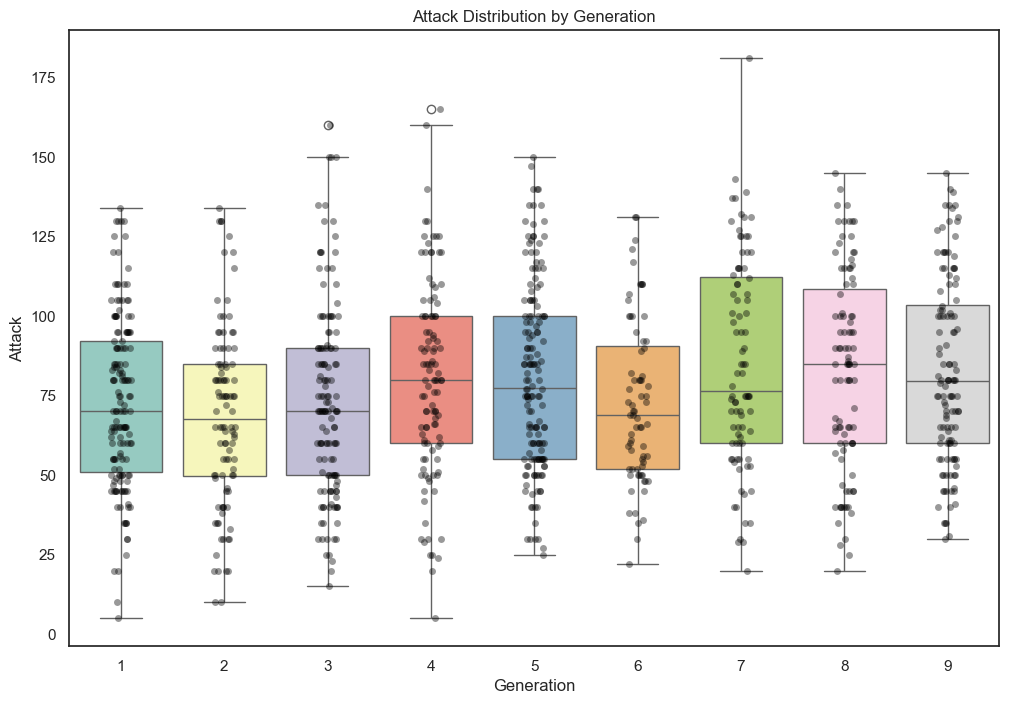

In [26]:
temp = pd.DataFrame()
temp['gen_int'] = df_data['gen'].astype(int)
temp['rarity'] = df_data['rarity']

plt.figure(figsize=(12, 8))
sns.boxplot(x=temp['gen_int'], y=df_labels['attack'], palette="Set3")
sns.stripplot(x=temp['gen_int'], y=df_labels['attack'], color='black', alpha=0.4, jitter=True)

# Calculate and print quantiles for each generation
quantiles = df_labels.groupby(temp['gen_int'])['attack'].quantile([0, 0.25, 0.5, 0.75, 1]).unstack()
print("Attack quantiles by generation:\n", quantiles)

plt.title("Attack Distribution by Generation")
plt.xlabel("Generation")
plt.ylabel("Attack")
plt.savefig("attack_by_generation_boxplot.png")
plt.show()


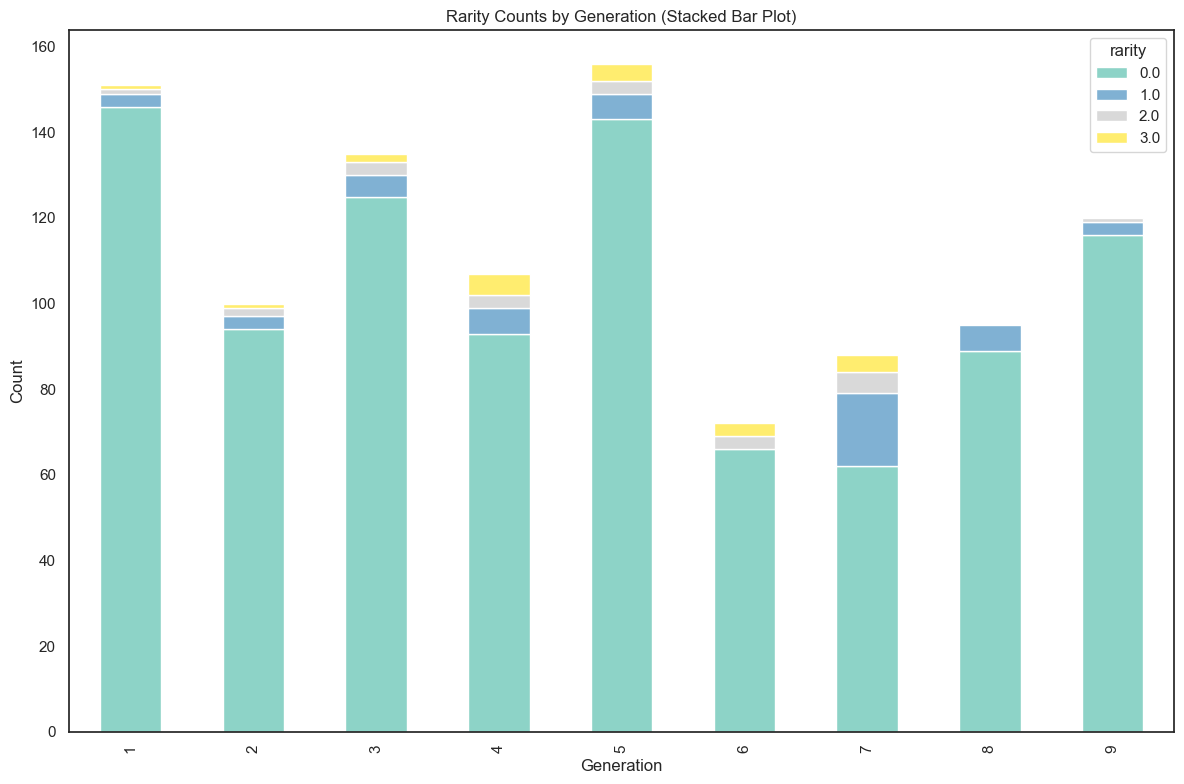

In [27]:
plt.figure(figsize=(12, 8))
rarity_counts = temp.groupby(['gen_int', 'rarity']).size().unstack(fill_value=0)
rarity_counts.plot(kind='bar', stacked=True, colormap='Set3', ax=plt.gca())

plt.title("Rarity Counts by Generation (Stacked Bar Plot)")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


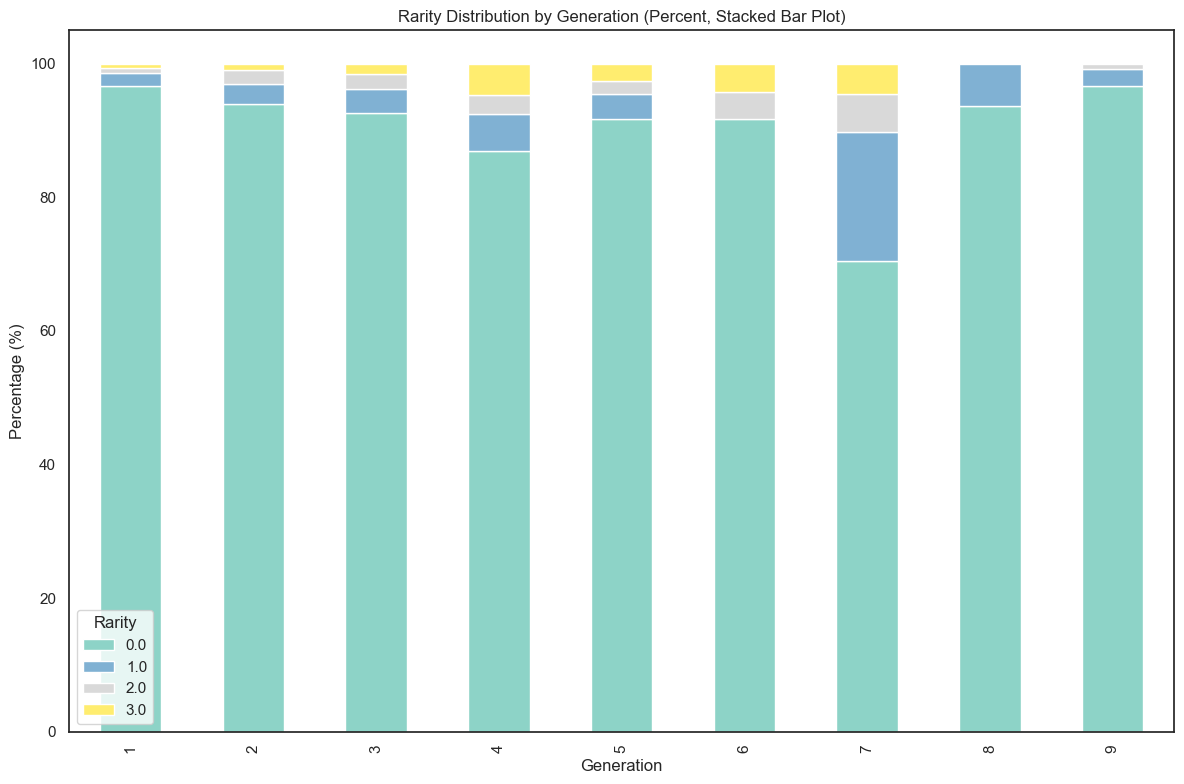

In [28]:
# Calculate rarity counts as percentages within each generation
rarity_percent = rarity_counts.div(rarity_counts.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
rarity_percent.plot(kind='bar', stacked=True, colormap='Set3', ax=plt.gca())

plt.title("Rarity Distribution by Generation (Percent, Stacked Bar Plot)")
plt.xlabel("Generation")
plt.ylabel("Percentage (%)")
plt.legend(title="Rarity")
plt.tight_layout()
plt.show()

### Outliers

Index(['gen', 'percent_male', 'percent_female', 'height_m', 'weight_kg',
       'capture_rate', 'base_egg_steps', 'hp', 'defense', 'sp_attack',
       'sp_defense', 'speed', 'against_normal', 'against_fire',
       'against_water', 'against_electric', 'against_grass', 'against_ice',
       'against_fighting', 'against_poison', 'against_ground',
       'against_flying', 'against_psychict', 'against_bug', 'against_rock',
       'against_ghost', 'against_dragon', 'against_dark', 'against_steel',
       'against_fairy', 'votes_first', 'votes_top_6', 'num_abilities',
       'evo_length', 'has_mega_evolution', 'has_gigantamax', 'rarity'],
      dtype='object')
outlier
 1    972
-1     52
Name: count, dtype: int64


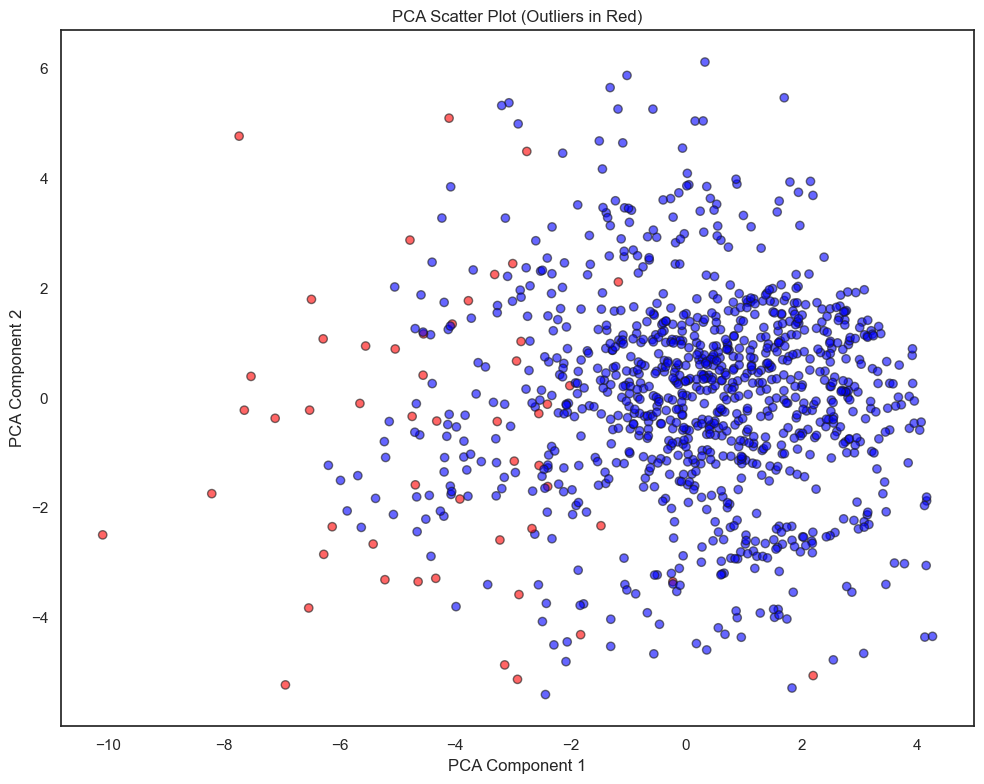

In [29]:
# Standardize all features in df_plot
scaler= StandardScaler()
pca = PCA(n_components=2)

print(df_data.columns)
outlier_data = df_data.copy().drop(['rarity'],axis=1)
df_plot_scaled = pd.DataFrame(scaler.fit_transform(outlier_data), columns=outlier_data.columns)
pca.fit(df_plot_scaled)

# Fit Isolation Forest for outlier detection
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_pred = iso.fit_predict(df_plot_scaled)

# Add outlier flag to dataframe: -1 is outlier, 1 is inlier
df_plot_scaled['outlier'] = outlier_pred
print(df_plot_scaled['outlier'].value_counts())

pca_data = pca.transform(df_plot_scaled.drop(columns=['outlier']))
plt.figure(figsize=(10, 8))
colors = np.where(df_plot_scaled['outlier'] == -1, 'red', 'blue')
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=colors, alpha=0.6, edgecolor='k')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA Scatter Plot (Outliers in Red)')
plt.tight_layout()
plt.show()

In [30]:
# Print names of the outliers, ordered by outlier score (most outlier-like first)
outlier_scores = iso.decision_function(df_plot_scaled.drop(columns=['outlier']))
outlier_mask = df_plot_scaled['outlier'] == -1
outlier_indices = np.where(outlier_mask)[0]
outlier_scores_selected = outlier_scores[outlier_indices]
outlier_names = df_names.loc[outlier_mask]
# Map rarity values to string labels
rarity_map = {0.0: "common", 1.0: "sublegendary", 2.0: "legendary", 3.0: "mythical"}
outlier_rarity = df_data.loc[outlier_mask, 'rarity']
outlier_rarity_str = outlier_rarity.map(rarity_map)

# Combine names, rarity (as string), and scores, sort by score ascending (most negative = most outlier)
outlier_df = pd.DataFrame({
    'name': outlier_names.values,
    'rarity': outlier_rarity_str.values,
    'score': outlier_scores_selected
})
outlier_df_sorted = outlier_df.sort_values('score').drop(columns=['score']).reset_index(drop=True)

print("Names and rarity of outliers ordered by Isolation Forest outlier score:")
print(outlier_df_sorted)

Names and rarity of outliers ordered by Isolation Forest outlier score:
           name        rarity
0        Gengar        common
1     Charizard        common
2     Stakataka  sublegendary
3      Melmetal        common
4     Tyranitar        common
5     Metagross        common
6      Rayquaza     legendary
7      Giratina     legendary
8        Latias  sublegendary
9      Guzzlord  sublegendary
10       Aggron        common
11      Steelix        common
12      Diancie      mythical
13       Latios  sublegendary
14    Eternatus        common
15       Lunala     legendary
16       Mewtwo     legendary
17      Lucario        common
18        Lugia     legendary
19       Celebi      mythical
20     Garchomp        common
21        Ho-Oh     legendary
22    Gardevoir        common
23      Cosmoem     legendary
24     Venusaur        common
25   Celesteela  sublegendary
26    Aegislash        common
27       Scizor        common
28   Copperajah        common
29       Zarude        commo

In [31]:
# Remove outliers from all relevant dataframes using outlier_mask
df_labels_no_outliers = df_labels.loc[~outlier_mask].reset_index(drop=True)
df_names_no_outliers = df_names.loc[~outlier_mask].reset_index(drop=True)
df_data_no_outliers = df_data.loc[~outlier_mask].reset_index(drop=True)

# Merge them into one DataFrame
df_no_outliers = pd.concat(
    [df_names_no_outliers, df_labels_no_outliers, df_data_no_outliers], axis=1
)

# Save to CSV
df_no_outliers.to_csv('../data/data_no_outliers.csv', index=False)


Outlier rarity counts:
 rarity
0.0    25
1.0    11
2.0    12
3.0     4
Name: count, dtype: int64
Outlier rarity percentages (%):
 rarity
0.0    48.08
1.0    21.15
2.0    23.08
3.0     7.69
Name: count, dtype: float64

Full population rarity counts:
 rarity
0.0    934
1.0     49
2.0     21
3.0     20
Name: count, dtype: int64
Full population rarity percentages (%):
 rarity
0.0    91.21
1.0     4.79
2.0     2.05
3.0     1.95
Name: count, dtype: float64


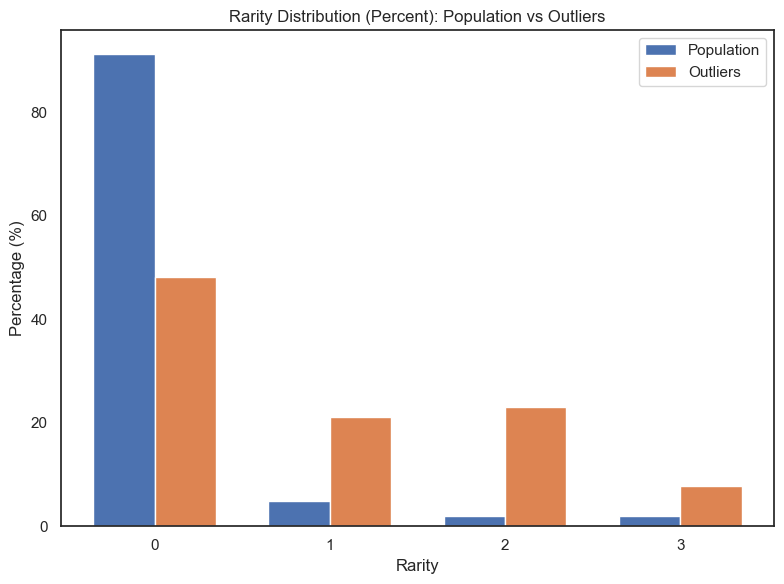

In [32]:
# Rarity of outliers
outlier_mask = outlier_pred == -1
rarity_outliers = temp.loc[outlier_mask, 'rarity']
rarity_full = temp['rarity']

# Count and percentage for outliers
outlier_counts = rarity_outliers.value_counts().sort_index()
outlier_percent = (outlier_counts / len(rarity_outliers) * 100).round(2)

print("Outlier rarity counts:\n", outlier_counts)
print("Outlier rarity percentages (%):\n", outlier_percent)

# Count and percentage for full population
full_counts = rarity_full.value_counts().sort_index()
full_percent = (full_counts / len(rarity_full) * 100).round(2)

print("\nFull population rarity counts:\n", full_counts)
print("Full population rarity percentages (%):\n", full_percent)


# Bar plot: percentages
plt.figure(figsize=(8, 6))
x = np.arange(len(full_percent))
bar_width = 0.35
plt.bar(x - bar_width/2, full_percent[x], width=bar_width, label='Population')
plt.bar(x + bar_width/2, outlier_percent[x], width=bar_width, label='Outliers')
plt.xlabel('Rarity')
plt.ylabel('Percentage (%)')
plt.title('Rarity Distribution (Percent): Population vs Outliers')
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()

### Classification via linear classifier

In [33]:
#calculate cross-validated accuracy for logistic regression predicting class_primary
X = df_data
y = df_labels['class_primary']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)
fold_acc = []
for i, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler_fold = StandardScaler()
    X_train_scaled = scaler_fold.fit_transform(X_train)
    X_val_scaled = scaler_fold.transform(X_val)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_val_scaled)

    acc = accuracy_score(y_val, y_pred)
    print(f"Fold {i} accuracy: {acc:.4f}")
    fold_acc.append(acc)

print(f"Mean CV accuracy: {np.mean(fold_acc):.4f} (+/- {np.std(fold_acc):.4f})")

Fold 1 accuracy: 0.9171
Fold 2 accuracy: 0.8634
Fold 3 accuracy: 0.8780
Fold 4 accuracy: 0.8927
Fold 5 accuracy: 0.9216
Mean CV accuracy: 0.8946 (+/- 0.0223)
